<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/04_7_%ED%8A%B9%EC%84%B1_%EC%9E%90%EB%8F%99_%EC%84%A0%ED%83%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 특성을 추가할 때나 고차원 데이터셋을 사용할 때, 과대적합을 방지하기 위해 가장 유용한 특성만 선택하고 나머지를 무시하여 특성의 수를 줄이는 것이 좋음
- 일변량 통계, 모델 기반 선택, 반복적 선택은 모두 지도 학습 방법 ➡️ 최적값을 찾으려면 타깃 값이 필요, 데이터를 훈련 세트와 테스트 세트를 나눈 후 훈련 데이터만 특성 선택에 사용해야 함

## 01 일변량 통계 (univariate statistics)
- 개개의 특성과 타깃 사이에 중요한 통계적 관계가 있는지를 계산한 후, 깊게 관련되어 있다고 판단되는 특성을 선택
- 분류에서는 **분산분석 (ANOVA)**라고도 함
- **일변량**: 각 특성이 독립적으로 평가됨 ➡️ 다른 특성과 깊게 연관된 특성은 선택되지 않을 것
- 계산이 매우 빠르고 평가를 위해 모델을 만들 필요가 없음, 모델에 상관없이 사용 가능
- scikit-learn에서의 일변량 분석
  - 분류에서는 `f_classif`, 회귀에서는 `f_regression`을 선택하여 테스트
  - 높은 p-value를 가진 (타깃 값과 연관성이 작은) 특성을 제외할 수 있또록 임계값을 조정하는 매개변수를 사용
    - `SelectKBest`: 고정된 k개의 특성을 선택
    - `SelectPercentile`: 지정된 비율만큼 특성을 선택


In [7]:
# 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

# 데이터에 노이즈 추가: 처음 30개는 원본 특성, 다음 50개는 노이즈
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))
X_w_noise = np.hstack([cancer.data, noise])

X_train, X_test, y_train, y_test = train_test_split(
    X_w_noise, cancer.target, random_state=0, test_size=.5
)

# 특성의 50%를 선택
select = SelectPercentile(score_func=f_classif, percentile=50)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)

print(f"X_train.shape: {X_train.shape}")
print(f"X_train_selected.shape: {X_train_select.shape}")

X_train.shape: (284, 80)
X_train_selected.shape: (284, 40)


[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


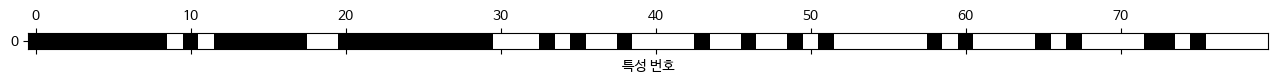

In [8]:
# SelectPercentile이 선택한 특성

# get_support(): 선택된 특성을 불리언 값으로 표시
mask = select.get_support()
print(mask)

plt.matshow(mask.reshape(1, -1), cmap="gray_r")
plt.xlabel("특성 번호")
plt.yticks([0])
plt.show()

In [9]:
# 전체 특성을 이용했을 때와 선택된 특성만을 사용했을 떄 로지스틱 회귀의 성능 비교
from sklearn.linear_model import LogisticRegression

X_test_selected = select.transform(X_test)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)
print(f"전체 특성을 사용한 점수: {round(lr.score(X_test, y_test), 3)}")

lr.fit(X_train_selected, y_train)
print(f"선택된 일부 특성을 사용한 점수: {round(lr.score(X_test_selected, y_test), 3)}")

전체 특성을 사용한 점수: 0.951
선택된 일부 특성을 사용한 점수: 0.933


## 02 모델 기반 특성 선택 (model-based selection)
- 지도 학습 머신러닝 모델을 사용하여 특성의 중요도를 평가해서 가장 중요한 특성들만 선택
- 특성 선택에서 사용하는 모델은 최종적으로 사용할 지도 학습 모델과 같을 필요는 없음
- 특성 선택을 위한 모델은 각 특성의 중요도를 측정하여 순서를 매길 수 있어야 함 (e.g. 결정 트리 기반 모델의 `feature_importances_`, 선형 모델 계수의 절대값, L1 규제를 사용하는 선형 모델이 선택한 특성)
- 한 번에 모든 특성을 고려 ➡️ (모델이 상호작용을 잡아낼 수 있다면) 상호작용 부분을 반영 가능

In [10]:
# SelectFromModel: 모델 기반의 특성 선택
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median"
)

- `SelectFromModel`: 지정한 임계치보다 큰 중요도를 가진 모든 특성을 선택

In [11]:
X_train_l1 = select.fit(X_train, y_train).transform(X_train)
print(f"X_train.shape: {X_train.shape}")
print(f"X_train_l1.shape: {X_train_l1.shape}")

X_train.shape: (284, 80)
X_train_l1.shape: (284, 40)


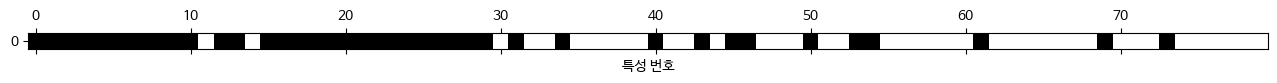

In [14]:
# RandomForestClassifier를 사용한 SelectFromModel이 선택한 특성

mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap="gray_r")
plt.xlabel("특성 번호")
plt.yticks([0])
plt.show()

In [16]:
# 성능

X_test_l1 = select.transform(X_test)
score = LogisticRegression(max_iter=5000).fit(X_train_l1, y_train).score(
    X_test_l1, y_test
)
print(f"테스트 점수: {round(score, 3)}")

테스트 점수: 0.947


## 03 반복적 특성 선택 (iterative selection)
- 특성의 수가 각기 다른 일련의 모델이 만들어짐
- 두 가지 방법
  - 1️⃣ 특성을 하나도 선택하지 않은 상태로 시작해서 어떤 종료 조건에 도달할 때까지 하나씩 추가
  - 2️⃣ 모든 특성을 가지고 시작해서 어떤 종료 조건이 될 때까지 특성을 하나씩 제거
- 더 많은 계산 비용 필요
- **재귀적 특성 제거** (RFE; recursive feature elimination)
  - 모든 특성으로 시작해서 모델을 만들고 특성 중요도가 가장 낮은 특성을 제거
  - 제거한 특성을 빼고 나머지 특성 전체로 새로운 모델을 만듦
  - 미리 정의한 특성 개수가 남을 때까지 반복

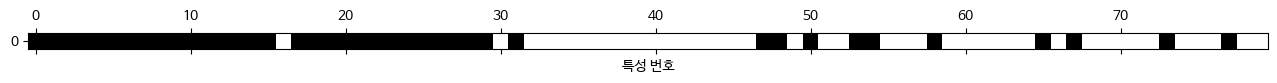

In [18]:
# 랜덤 포레스트 분류 모델을 사용한 RFE가 선택한 특성
from sklearn.feature_selection import RFE

select = RFE(RandomForestClassifier(n_estimators=100, random_state=42),
             n_features_to_select=40)

select.fit(X_train, y_train)
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap="gray_r")
plt.xlabel("특성 번호")
plt.yticks([0])
plt.show()

In [19]:
X_train_rfe = select.transform(X_train)
X_test_rfe = select.transform(X_test)

score = LogisticRegression(max_iter=5000).fit(X_train_rfe, y_train).score(
    X_test_rfe, y_test
)
print(f"테스트 점수: {round(score, 3)}")

테스트 점수: 0.94


In [20]:
# RFE에 사용된 모델을 이용한 예측 (선택된 특성만 사용)
print(f"테스트 점수: {round(select.score(X_test, y_test), 3)}")

테스트 점수: 0.951


- 예측 속도를 높이거나 해석하기 더 쉬운 모델을 만드는 데 필요한 만큼 특성의 수를 줄이는 데도 효과적
- 실전에서는 특성 선택이 큰 성능 향상을 끌어내지 못하는 경우가 많음